In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep


scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
# Metadata file:
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

organ = 'Brain'

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 7856
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [4]:
metadata["cell_id"] = metadata.index
metadata.head()

,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,cell_id
cell,,,,,,,
A1-B003290-3_38_F-1-1,astrocyte,NaN,3_38_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003290-3_38_F-1-1
A1-B003728-3_56_F-1-1,astrocyte,NaN,3_56_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003728-3_56_F-1-1
A1-MAA000560-3_10_M-1-1,oligodendrocyte,NaN,3_10_M,Cortex,Brain_Non-Myeloid,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1
A1-MAA000564-3_10_M-1-1,endothelial cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1
A1-MAA000923-3_9_M-1-1,astrocyte,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-MAA000923-3_9_M-1-1


In [5]:
# keep cell_type as everything after "Myeloid_"
metadata.cell_type = metadata.cell_type.str.split("Myeloid_").str[1]
metadata.cell_type.unique() 

array(['astrocyte', 'oligodendrocyte', 'endothelial_cell', 'neuron',
       'oligodendrocyte_precursor_cell', 'Bergmann_glial_cell',
       'brain_pericyte', 'microglial_cell', 'macrophage'], dtype=object)

In [29]:
# load PCA and UMAP representations of brain data using gene counts 
PCA_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_pca_embedding.csv')
UMAP_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_umap_embedding.csv')

#Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')

In [30]:
UMAP_rep

,Unnamed: 0,UMAP_0,UMAP_1,cell_id,cell_type
0,0,15.781493,1.732195,A12-MAA000926-3_9_M-1-1,oligodendrocyte precursor cell
1,1,13.505811,2.711557,A16-MAA000564-3_10_M-1-1,oligodendrocyte precursor cell
2,2,15.700276,1.656008,A20-MAA000550-3_10_M-1-1,oligodendrocyte precursor cell
3,3,15.032517,1.633028,A20-MAA000947-3_9_M-1-1,oligodendrocyte precursor cell
4,4,15.566546,2.164053,A3-MAA000560-3_10_M-1-1,oligodendrocyte precursor cell
...,...,...,...,...,...
7555,7555,8.475939,9.544691,P9-MAA000592-3_9_M-1-1,microglial cell
7556,7556,7.741404,10.259892,P9-MAA000593-3_8_M-1-1,microglial cell
7557,7557,8.680904,9.796571,P9-MAA000603-3_10_M-1-1,microglial cell
7558,7558,7.332836,9.591975,P9-MAA000604-3_10_M-1-1,microglial cell


In [7]:
UMAP_rep.drop(columns=['Unnamed: 0'], inplace=True)
UMAP_rep.drop(columns = ['cell_type'], inplace=True)
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id
0,15.781493,1.732195,A12-MAA000926-3_9_M-1-1
1,13.505811,2.711557,A16-MAA000564-3_10_M-1-1
2,15.700276,1.656008,A20-MAA000550-3_10_M-1-1
3,15.032517,1.633028,A20-MAA000947-3_9_M-1-1
4,15.566546,2.164053,A3-MAA000560-3_10_M-1-1


In [8]:
Leaflet_rep.drop(columns=['Unnamed: 0'], inplace=True)
Leaflet_rep.drop(columns=['cell_type'], inplace=True)
Leaflet_rep['cell_id'] = [x.split('_B')[0] for x in Leaflet_rep['cell_id']]
Leaflet_rep.head()

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cell_id
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000581-3_10_M-1-1
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000930-3_8_M-1-1
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A14-MAA000947-3_9_M-1-1
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A15-MAA000561-3_10_M-1-1
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,A19-MAA000581-3_10_M-1-1


In [9]:
UMAP_rep = UMAP_rep.merge(metadata, on=['cell_id'], how='left')
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type
0,15.781493,1.732195,A12-MAA000926-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
1,13.505811,2.711557,A16-MAA000564-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
2,15.700276,1.656008,A20-MAA000550-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
3,15.032517,1.633028,A20-MAA000947-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
4,15.566546,2.164053,A3-MAA000560-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell


In [10]:
# combine UMAP and BB mixture results
UMAP_rep = UMAP_rep.merge(Leaflet_rep, on='cell_id', how='left')

In [11]:
UMAP_rep.cell_type.unique()

array(['oligodendrocyte_precursor_cell', 'macrophage', 'endothelial_cell',
       'oligodendrocyte', 'brain_pericyte', 'Bergmann_glial_cell',
       'neuron', 'astrocyte', 'microglial_cell'], dtype=object)

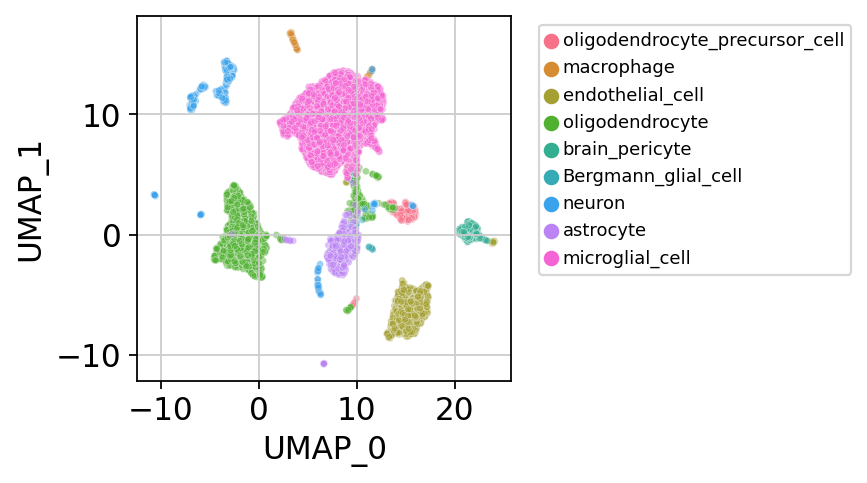

oligodendrocyte_precursor_cell: (0.9677975592919913, 0.44127456009157356, 0.5358103155058701)
macrophage: (0.8369430560927636, 0.5495828952802333, 0.1952683223448124)
endothelial_cell: (0.6430915736746491, 0.6271955086583126, 0.19381135329796756)
oligodendrocyte: (0.3126890019504329, 0.6928754610296064, 0.1923704830330379)
brain_pericyte: (0.20582072623426667, 0.6842209016721069, 0.5675558225732941)
Bergmann_glial_cell: (0.2151139535594307, 0.6700707833028816, 0.7112365203426209)
neuron: (0.23299120924703914, 0.639586552066035, 0.9260706093977744)
astrocyte: (0.731751635642941, 0.5128186367840487, 0.9581005178234921)
microglial_cell: (0.9614880299080136, 0.3909885385134758, 0.8298287106954371)


In [12]:
# 1. Define a color palette for 'cell_type'
unique_cell_types = UMAP_rep['cell_type'].unique()
palette = sns.color_palette("husl", len(unique_cell_types))
color_mapping = dict(zip(unique_cell_types, palette))

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cell_type'], palette=color_mapping, alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

# Print color mapping for reference
for cell_type, color in color_mapping.items():
    print(f"{cell_type}: {color}")

In [13]:
UMAP_rep.cell_type.unique()

array(['oligodendrocyte_precursor_cell', 'macrophage', 'endothelial_cell',
       'oligodendrocyte', 'brain_pericyte', 'Bergmann_glial_cell',
       'neuron', 'astrocyte', 'microglial_cell'], dtype=object)

In [14]:
# figure out which CellState has a value of 1 and assign that cell state number of the cell 
# find columns that have CellState in them?
cellstates = [col for col in UMAP_rep.columns if 'CellState' in col]
UMAP_rep["cellassignment"] = UMAP_rep[cellstates].idxmax(axis=1)

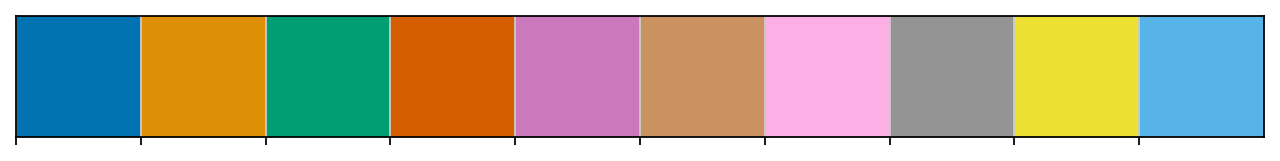

In [15]:
sns.palplot(sns.color_palette("colorblind"))


{'CellState_1': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'CellState_10': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'CellState_2': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), 'CellState_3': (0.8352941176470589, 0.3686274509803922, 0.0), 'CellState_4': (0.8, 0.47058823529411764, 0.7372549019607844), 'CellState_5': (0.792156862745098, 0.5686274509803921, 0.3803921568627451), 'CellState_6': (0.984313725490196, 0.6862745098039216, 0.8941176470588236), 'CellState_7': (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), 'CellState_8': (0.9254901960784314, 0.8823529411764706, 0.2), 'CellState_9': (0.33725490196078434, 0.7058823529411765, 0.9137254901960784), nan: (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)}


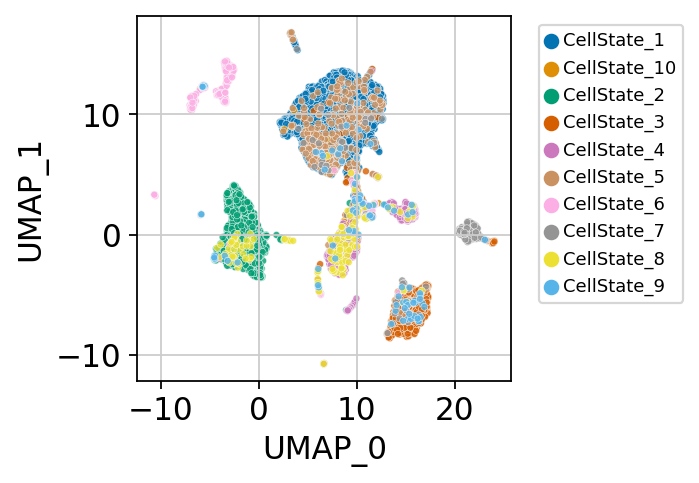

In [16]:
# Sort UMAP_rep by cellassignment
UMAP_rep = UMAP_rep.sort_values(by='cellassignment')

# Create a color mapping for each unique cellassignment
unique_states = UMAP_rep['cellassignment'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

print(color_mapping)

# Plot
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cellassignment'], palette=color_mapping, alpha=0.8, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

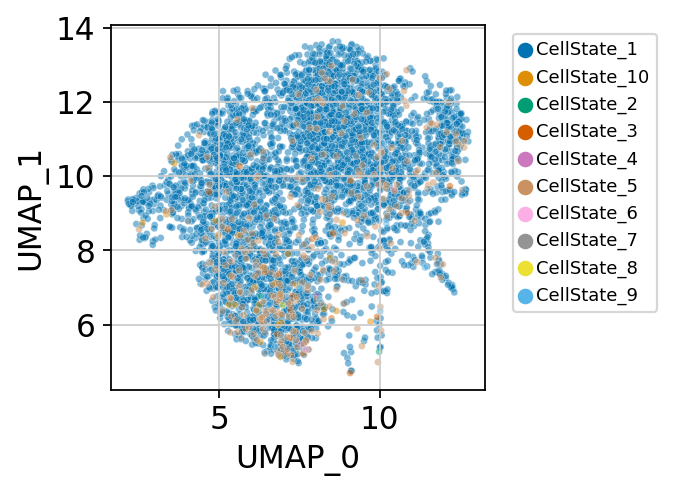

CellState_1     3999
CellState_5      273
CellState_10      26
CellState_7       21
CellState_3       19
CellState_9       12
CellState_4        3
CellState_2        2
CellState_6        1
CellState_8        1
Name: cellassignment, dtype: int64

In [17]:
# 1. Filter the dataframe
filt_dat = UMAP_rep[UMAP_rep['cell_type'] == "microglial_cell"]

# Subset the color mapping to only include the states of interest
subset_color_mapping = {k: color_mapping[k] for k in filt_dat.cellassignment.unique() if k in color_mapping}

# 2. & 3. Plot using hue and the subset color mapping
plt.figure(figsize=(3, 3))
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cellassignment'], palette=subset_color_mapping, alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='xx-small')
plt.show()

# print how much each cellstate contributes to tehse cells in microglia 
filt_dat.cellassignment.value_counts()

### basically gene expression can't really seperate macrophages 

In [18]:
UMAP_rep[UMAP_rep["cell_type"] == "macrophage"][("cellassignment")].value_counts()

CellState_1    41
CellState_5     9
CellState_7     2
Name: cellassignment, dtype: int64

In [19]:
UMAP_rep[UMAP_rep["cell_type"] == "microglial_cell"][("cellassignment")].value_counts()

CellState_1     3999
CellState_5      273
CellState_10      26
CellState_7       21
CellState_3       19
CellState_9       12
CellState_4        3
CellState_2        2
CellState_6        1
CellState_8        1
Name: cellassignment, dtype: int64

In [20]:
UMAP_rep[UMAP_rep["cell_type"] == "brain_pericyte"][("cellassignment")].value_counts()

CellState_7    138
CellState_5      2
CellState_3      1
CellState_9      1
Name: cellassignment, dtype: int64

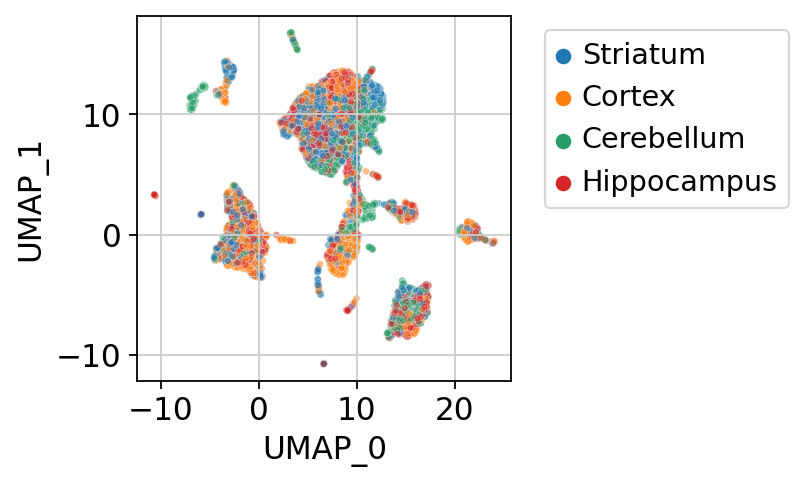

In [21]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['subtissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

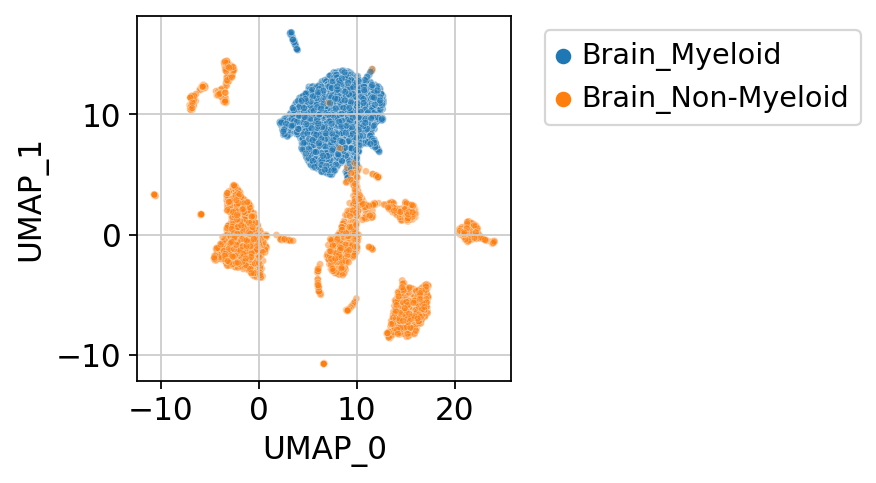

In [22]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['tissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
UMAP_rep["cellassignment"].value_counts()

CellState_1     4053
CellState_2     1236
CellState_3      649
CellState_4      464
CellState_5      357
CellState_6      251
CellState_7      196
CellState_8      162
CellState_9       87
CellState_10      77
Name: cellassignment, dtype: int64

In [25]:
UMAP_rep[["cellassignment", "mouse.id"]][["mouse.id", "cellassignment"]].value_counts()

mouse.id  cellassignment
3_10_M    CellState_1       934
3_38_F    CellState_1       873
3_39_F    CellState_1       804
3_9_M     CellState_1       621
3_8_M     CellState_1       535
                           ... 
3_11_M    CellState_10        4
3_56_F    CellState_9         2
3_11_M    CellState_1         2
          CellState_5         2
3_8_M     CellState_10        2
Length: 70, dtype: int64

In [28]:
UMAP_rep

,UMAP_0,UMAP_1,cell_id,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cellassignment
3793,5.543876,8.481112,C18-B000825-3_38_F-1-1,microglial cell,NaN,3_38_F,Striatum,Brain_Myeloid,microglial_cell,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_1
4960,5.591268,10.144571,H17-B001176-3_56_F-1-1,microglial cell,NaN,3_56_F,Striatum,Brain_Myeloid,microglial_cell,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_1
4959,4.547886,11.194583,H17-B000826-3_39_F-1-1,microglial cell,NaN,3_39_F,Cortex,Brain_Myeloid,microglial_cell,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_1
4958,5.569184,5.991549,H17-B000825-3_38_F-1-1,microglial cell,NaN,3_38_F,Striatum,Brain_Myeloid,microglial_cell,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_1
4957,9.861121,9.293321,H16-MAA000617-3_10_M-1-1,microglial cell,NaN,3_10_M,Striatum,Brain_Myeloid,microglial_cell,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CellState_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2526,9.961201,0.744118,O11-B000404-3_56_F-1-1,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2527,8.430540,-1.116672,O16-MAA000928-3_9_M-1-1,Bergmann glial cell,NaN,3_9_M,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2528,11.247070,-1.011639,O18-B000404-3_56_F-1-1,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2529,9.939075,0.836422,O19-B000404-3_56_F-1-1,Bergmann glial cell,NaN,3_56_F,Cerebellum,Brain_Non-Myeloid,Bergmann_glial_cell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


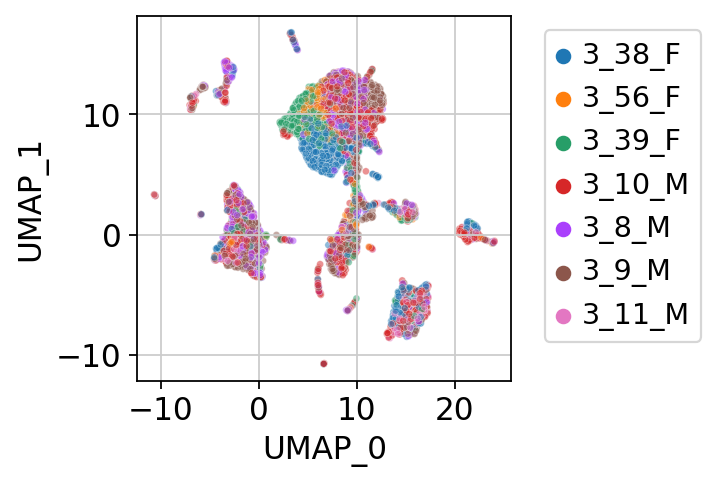

In [26]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['mouse.id'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()